# CWRU Bookstore Survey — Gender-Stratified Analysis & T-Tests

This notebook extends the cleaning notebook's descriptive statistics by:
- Breaking down key survey dimensions by gender
- Running Welch's t-tests to check whether male/female differences are statistically significant
- Producing new visualizations not already in the cleaning notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

df = pd.read_csv('Cleaned_BookstoreSurvey.csv', skiprows=[1])
n = len(df)
print(f"Total respondents: {n}")
print("\nGender breakdown:")
print(df['Q3'].value_counts())
print("\nYear in school:")
print(df['Q2'].value_counts())

Total respondents: 49

Gender breakdown:
Q3
Male          28
Female        19
Non-binary     2
Name: count, dtype: int64

Year in school:
Q2
Junior       17
Senior       11
Sophomore    11
Freshman     10
Name: count, dtype: int64


## Data Encoding

Converts Likert-scale and spending responses into ordinal integers so we can compute means and run t-tests. Non-binary respondents (n=2) are kept in categorical plots but excluded from Male vs. Female t-tests.

In [2]:
likelihood_map = {
    '1- Very unlikely': 1, '1-  Very unlikely': 1,
    '2- Unlikely': 2,      '2-  Unlikely': 2,
    '3- Likely': 3,        '3-  Likely': 3,
    '4- Very likely': 4,   '4-  Very likely': 4,
}
spending_map = {'<$10': 1, '$10 - $20': 2, '$20 - $30': 3,
                '$30 - $40': 4, '$40 - $50': 5, '$50+': 6}

df['purchase_score']    = df['Q26'].map(likelihood_map)
df['online_ad_score']   = df['Q18'].map(likelihood_map)
df['inperson_ad_score'] = df['Q21'].map(likelihood_map)
df['avg_spend_score']   = df['Q24'].map(spending_map)
df['max_spend_score']   = df['Q23'].map(spending_map)
df['gender']            = df['Q3'].str.strip()

df_mf  = df[df['gender'].isin(['Male', 'Female'])].copy()
male   = df_mf[df_mf['gender'] == 'Male']
female = df_mf[df_mf['gender'] == 'Female']
print(f"Male: {len(male)}, Female: {len(female)}")

Male: 28, Female: 19


## Gender-Stratified Descriptive Statistics

Frequency tables expressed as percentages within each gender group, so unequal group sizes (28 male, 19 female) do not distort comparisons.

In [3]:
def gender_pct_table(label, col, order=None):
    ct = pd.crosstab(df_mf[col], df_mf['gender'])
    pct = ct.div(ct.sum(axis=0), axis=1).mul(100).round(1)
    if order:
        pct = pct.reindex([x for x in order if x in pct.index])
    print(f"\n{'='*60}")
    print(f"{label}")
    print('='*60)
    print(pct.to_string())

gender_pct_table(
    'Purchase Intent Next Semester (Q26)',
    'Q26',
    order=['1- Very unlikely', '2-  Unlikely', '3- Likely', '4- Very likely']
)
gender_pct_table(
    'Avg Spend per Item (Q24)',
    'Q24',
    order=['<$10', '$10 - $20', '$20 - $30', '$30 - $40', '$40 - $50', '$50+']
)
gender_pct_table(
    'Max Spend Last 3 Months (Q23)',
    'Q23',
    order=['<$10', '$10 - $20', '$20 - $30', '$30 - $40', '$40 - $50', '$50+']
)
gender_pct_table(
    'Color Style Preference (Q12)',
    'Q12',
    order=['School colors (blue, white)', 'Neutral colors (black, white, gray)', 'Pastel colors']
)
gender_pct_table(
    'Logo Size Preference (Q9)',
    'Q9',
    order=['Small', 'Medium', 'Large']
)
gender_pct_table(
    'Most Important Purchase Factor (Q8)',
    'Q8',
    order=['Price', 'Style', 'Comfort']
)
gender_pct_table(
    'Online Ad Type Preference (Q17)',
    'Q17',
    order=['Discounts/sales', 'Student promotions', 'New apparel announcements']
)


Purchase Intent Next Semester (Q26)
gender            Female  Male
Q26                           
1- Very unlikely    31.6  32.1
2-  Unlikely        42.1  39.3
3- Likely           21.1  25.0
4- Very likely       5.3   3.6

Avg Spend per Item (Q24)
gender     Female  Male
Q24                    
<$10          0.0   7.1
$10 - $20    21.1  25.0
$20 - $30    42.1  28.6
$30 - $40     5.3  14.3
$40 - $50    15.8  14.3
$50+         15.8  10.7

Max Spend Last 3 Months (Q23)
gender     Female  Male
Q23                    
<$10          5.3  21.4
$10 - $20    10.5  10.7
$20 - $30    15.8  10.7
$30 - $40    21.1  21.4
$40 - $50     5.3   7.1
$50+         42.1  28.6

Color Style Preference (Q12)
gender                               Female  Male
Q12                                              
School colors (blue, white)            42.1  57.1
Neutral colors (black, white, gray)    52.6  21.4
Pastel colors                           5.3  21.4

Logo Size Preference (Q9)
gender  Female  Male
Q9      

## T-Test Analysis: Male vs. Female

Welch's independent-samples t-test (does not assume equal variances). With n=28 male and n=19 female, power is limited — treat significant results as directional signals rather than definitive conclusions.

In [4]:
tests = [
    ('Purchase Likelihood (Q26)',       'purchase_score'),
    ('Online Ad Likelihood (Q18)',       'online_ad_score'),
    ('In-Person Ad Likelihood (Q21)',    'inperson_ad_score'),
    ('Avg Spend Score (Q24)',            'avg_spend_score'),
    ('Max Spend Score (Q23)',            'max_spend_score'),
]

print("Welch's t-tests: Male vs Female")
print(f"{'Variable':<35} {'Male':>7} {'Female':>8} {'t':>7} {'p':>8} {'Sig.':>6}")
print('-' * 76)

ttest_rows = []
for label, col in tests:
    m = male[col].dropna()
    f = female[col].dropna()
    t, p = ttest_ind(m, f, equal_var=False)
    sig = '* ' if p < 0.05 else '  '
    ttest_rows.append(dict(label=label, col=col, male_mean=m.mean(),
                           female_mean=f.mean(), t=t, p=p, sig=sig.strip()))
    print(f"{label:<35} {m.mean():>7.2f} {f.mean():>8.2f} {t:>7.3f} {p:>8.4f} {sig:>6}")

print("\n* = significant at p < 0.05")
print(f"n_male={len(male)}, n_female={len(female)} — small sample, interpret with caution.")

Welch's t-tests: Male vs Female
Variable                               Male   Female       t        p   Sig.
----------------------------------------------------------------------------
Purchase Likelihood (Q26)              2.00     2.00   0.000   1.0000       
Online Ad Likelihood (Q18)             1.75     1.84  -0.447   0.6573       
In-Person Ad Likelihood (Q21)          1.89     2.11  -1.114   0.2712       
Avg Spend Score (Q24)                  3.36     3.63  -0.640   0.5257       
Max Spend Score (Q23)                  3.68     4.37  -1.304   0.1993       

* = significant at p < 0.05
n_male=28, n_female=19 — small sample, interpret with caution.


## Visualizations

### Figure 1 — Purchase Intent by Gender (Stacked 100% Bar)

Shows what share of each gender falls into each purchase intent category. A stacked 100% bar normalizes for unequal group sizes.

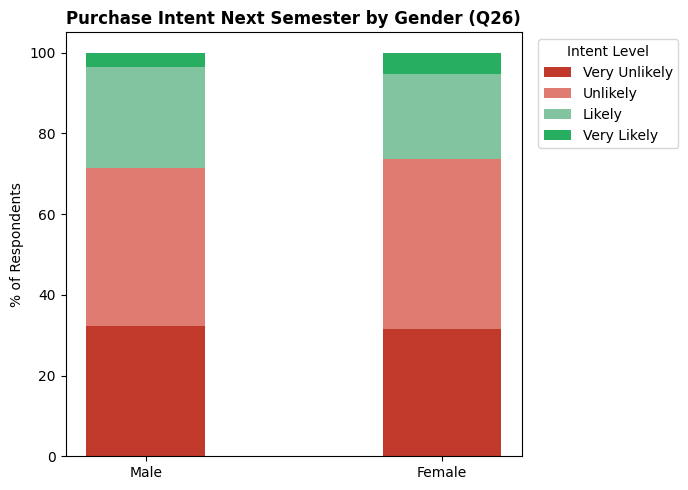

In [5]:
intent_order = ['1- Very unlikely', '2-  Unlikely', '3- Likely', '4- Very likely']
intent_labels = ['Very Unlikely', 'Unlikely', 'Likely', 'Very Likely']
colors_intent = ['#c0392b', '#e07b72', '#82c4a0', '#27ae60']

ct = pd.crosstab(df_mf['Q26'], df_mf['gender'])
ct = ct.reindex([x for x in intent_order if x in ct.index])
pct = ct.div(ct.sum(axis=0), axis=1).mul(100)
pct.index = intent_labels[:len(pct)]

fig, ax = plt.subplots(figsize=(7, 5))
bottom_m = np.zeros(len(pct))
bottom_f = np.zeros(len(pct))
for i, row_label in enumerate(pct.index):
    ax.bar(['Male'], pct.loc[row_label, 'Male'],   bottom=bottom_m[0], color=colors_intent[i], label=row_label, width=0.4)
    ax.bar(['Female'], pct.loc[row_label, 'Female'], bottom=bottom_f[0], color=colors_intent[i], width=0.4)
    bottom_m[0] += pct.loc[row_label, 'Male']
    bottom_f[0] += pct.loc[row_label, 'Female']

ax.set_ylabel('% of Respondents')
ax.set_title('Purchase Intent Next Semester by Gender (Q26)', fontweight='bold')
ax.legend(title='Intent Level', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

### Figure 2 — Mean Scores by Gender with T-Test Significance

Grouped bar chart of mean scores for each numeric variable, with an asterisk above any pair where the t-test was significant at p < 0.05.

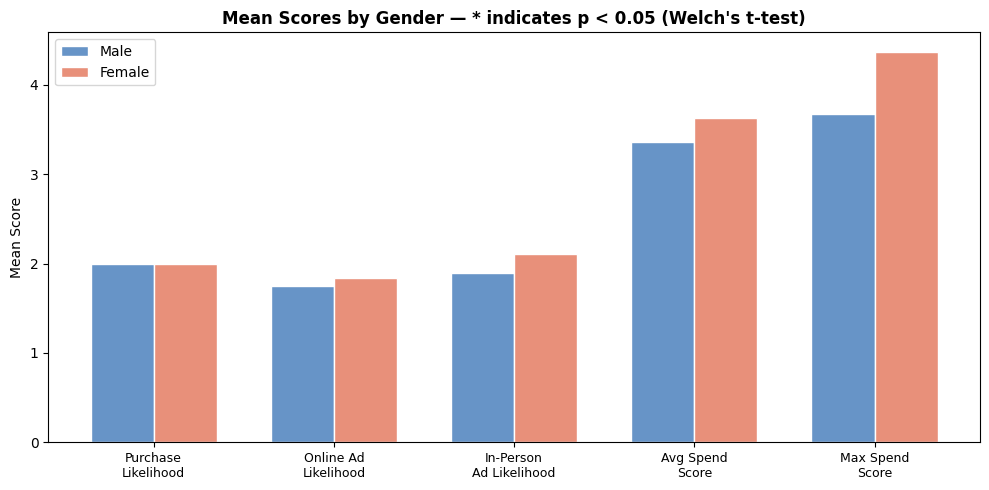

In [6]:
short_labels = ['Purchase\nLikelihood', 'Online Ad\nLikelihood',
                'In-Person\nAd Likelihood', 'Avg Spend\nScore', 'Max Spend\nScore']

male_means   = [r['male_mean']   for r in ttest_rows]
female_means = [r['female_mean'] for r in ttest_rows]
sig_flags    = [r['sig'] == '*'  for r in ttest_rows]

x = np.arange(len(short_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_m = ax.bar(x - w/2, male_means,   width=w, label='Male',   color='#6794c7', edgecolor='white')
bars_f = ax.bar(x + w/2, female_means, width=w, label='Female', color='#e8907a', edgecolor='white')

for i, sig in enumerate(sig_flags):
    if sig:
        y_max = max(male_means[i], female_means[i]) + 0.15
        ax.text(x[i], y_max, '*', ha='center', va='bottom', fontsize=14, color='black')

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylabel('Mean Score')
ax.set_title("Mean Scores by Gender — * indicates p < 0.05 (Welch's t-test)", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Figure 3 — Spending Distribution by Gender

Side-by-side violin + strip plots for average spend (Q24) and max spend (Q23) by gender, showing both spread and individual data points given the small sample.

/var/folders/7v/dvn79ckd5wbfdc_5cnlzx8yw0000gn/T/ipykernel_84429/4194766161.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_mf, x='gender', y=col, palette={'Male': '#6794c7', 'Female': '#e8907a'},
/var/folders/7v/dvn79ckd5wbfdc_5cnlzx8yw0000gn/T/ipykernel_84429/4194766161.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_mf, x='gender', y=col, palette={'Male': '#3a5f8a', 'Female': '#b84f36'},
/var/folders/7v/dvn79ckd5wbfdc_5cnlzx8yw0000gn/T/ipykernel_84429/4194766161.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.vio

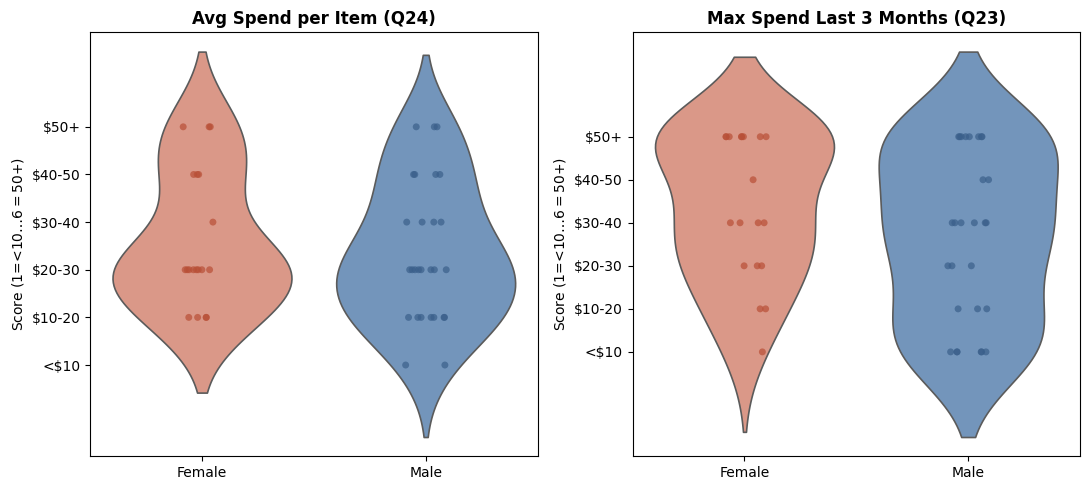

In [7]:
spend_labels = {1: '<$10', 2: '$10-20', 3: '$20-30', 4: '$30-40', 5: '$40-50', 6: '$50+'}

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col, title in zip(axes,
                          ['avg_spend_score', 'max_spend_score'],
                          ['Avg Spend per Item (Q24)', 'Max Spend Last 3 Months (Q23)']):
    sns.violinplot(data=df_mf, x='gender', y=col, palette={'Male': '#6794c7', 'Female': '#e8907a'},
                   inner=None, ax=ax, linewidth=1.2)
    sns.stripplot(data=df_mf, x='gender', y=col, palette={'Male': '#3a5f8a', 'Female': '#b84f36'},
                  jitter=True, size=5, alpha=0.7, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score (1=<$10 … 6=$50+)')
    ax.set_yticks(range(1, 7))
    ax.set_yticklabels([spend_labels[i] for i in range(1, 7)])

plt.tight_layout()
plt.show()

### Figure 4 — Design Preferences by Gender

Two grouped bar panels: color style preference (Q12) and logo size preference (Q9). These map directly to MDP 2 — product design decisions.

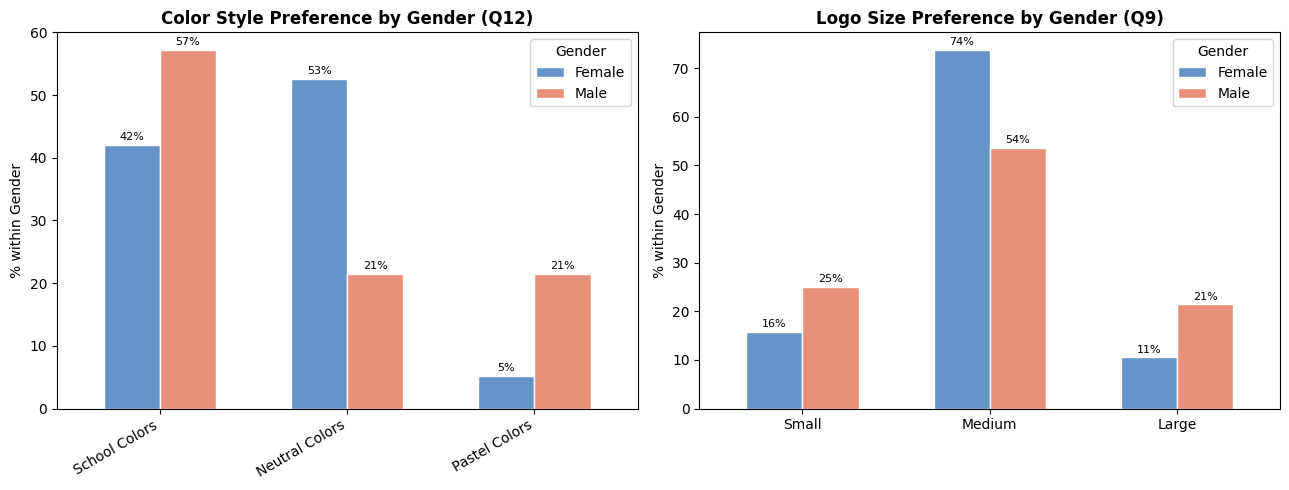

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Color preference
color_order = ['School colors (blue, white)', 'Neutral colors (black, white, gray)', 'Pastel colors']
color_short  = ['School Colors', 'Neutral Colors', 'Pastel Colors']
ct_color = pd.crosstab(df_mf['Q12'], df_mf['gender'])
ct_color = ct_color.reindex([c for c in color_order if c in ct_color.index])
pct_color = ct_color.div(ct_color.sum(axis=0), axis=1).mul(100).fillna(0)
pct_color.index = color_short[:len(pct_color)]
pct_color.plot(kind='bar', ax=axes[0], color=['#6794c7', '#e8907a'], edgecolor='white', width=0.6)
axes[0].set_title('Color Style Preference by Gender (Q12)', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('% within Gender')
axes[0].set_xticklabels(color_short[:len(pct_color)], rotation=30, ha='right')
axes[0].legend(title='Gender')
for c in axes[0].containers:
    axes[0].bar_label(c, fmt='%.0f%%', label_type='edge', fontsize=8, padding=2)

# Logo size
logo_order = ['Small', 'Medium', 'Large']
ct_logo = pd.crosstab(df_mf['Q9'], df_mf['gender'])
ct_logo = ct_logo.reindex([l for l in logo_order if l in ct_logo.index])
pct_logo = ct_logo.div(ct_logo.sum(axis=0), axis=1).mul(100).fillna(0)
pct_logo.plot(kind='bar', ax=axes[1], color=['#6794c7', '#e8907a'], edgecolor='white', width=0.6)
axes[1].set_title('Logo Size Preference by Gender (Q9)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('% within Gender')
axes[1].set_xticklabels(logo_order, rotation=0)
axes[1].legend(title='Gender')
for c in axes[1].containers:
    axes[1].bar_label(c, fmt='%.0f%%', label_type='edge', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

### Figure 5 — Most Important Purchase Factor by Gender

Price vs. Style vs. Comfort split by gender. If female respondents are more style-driven, that suggests different messaging strategies for each segment.

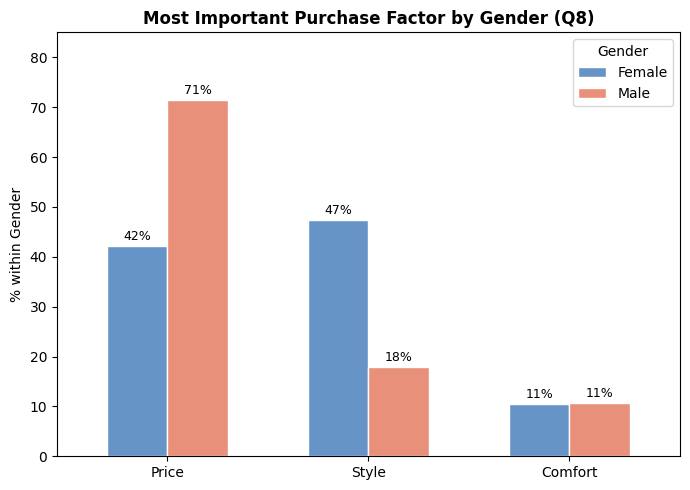

In [9]:
factor_order = ['Price', 'Style', 'Comfort']
ct_factor = pd.crosstab(df_mf['Q8'], df_mf['gender'])
ct_factor = ct_factor.reindex([f for f in factor_order if f in ct_factor.index])
pct_factor = ct_factor.div(ct_factor.sum(axis=0), axis=1).mul(100).fillna(0)

fig, ax = plt.subplots(figsize=(7, 5))
pct_factor.plot(kind='bar', ax=ax, color=['#6794c7', '#e8907a'], edgecolor='white', width=0.6)
ax.set_title('Most Important Purchase Factor by Gender (Q8)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% within Gender')
ax.set_xticklabels(factor_order, rotation=0)
ax.legend(title='Gender')
for c in ax.containers:
    ax.bar_label(c, fmt='%.0f%%', label_type='edge', fontsize=9, padding=2)
ax.set_ylim(0, 85)
plt.tight_layout()
plt.show()

### Figure 6 — Ad Responsiveness Box Plots by Gender

Box plots for online (Q18) and in-person (Q21) ad purchase likelihood, split by gender. Overlaid data points show individual responses given the small n.

/var/folders/7v/dvn79ckd5wbfdc_5cnlzx8yw0000gn/T/ipykernel_84429/3264783077.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_mf, x='gender', y=col, palette={'Male': '#6794c7', 'Female': '#e8907a'},
/var/folders/7v/dvn79ckd5wbfdc_5cnlzx8yw0000gn/T/ipykernel_84429/3264783077.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_mf, x='gender', y=col, palette={'Male': '#3a5f8a', 'Female': '#b84f36'},
/var/folders/7v/dvn79ckd5wbfdc_5cnlzx8yw0000gn/T/ipykernel_84429/3264783077.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxp

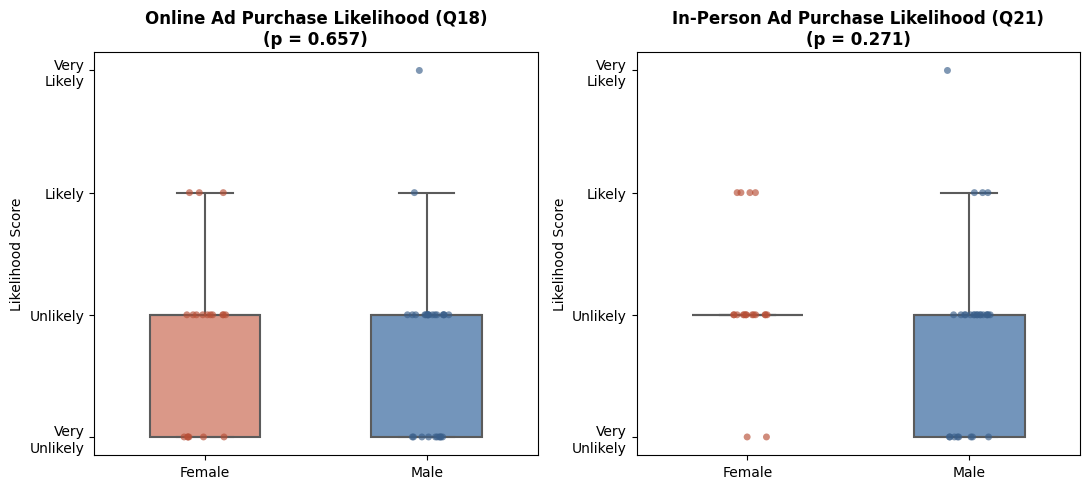

In [10]:
likelihood_labels = {1: 'Very\nUnlikely', 2: 'Unlikely', 3: 'Likely', 4: 'Very\nLikely'}

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, col, title, p_val in zip(
    axes,
    ['online_ad_score', 'inperson_ad_score'],
    ['Online Ad Purchase Likelihood (Q18)', 'In-Person Ad Purchase Likelihood (Q21)'],
    [next(r['p'] for r in ttest_rows if r['col'] == 'online_ad_score'),
     next(r['p'] for r in ttest_rows if r['col'] == 'inperson_ad_score')]
):
    sns.boxplot(data=df_mf, x='gender', y=col, palette={'Male': '#6794c7', 'Female': '#e8907a'},
                width=0.5, ax=ax, linewidth=1.5, fliersize=0)
    sns.stripplot(data=df_mf, x='gender', y=col, palette={'Male': '#3a5f8a', 'Female': '#b84f36'},
                  jitter=True, size=5, alpha=0.65, ax=ax)
    sig_note = f'p = {p_val:.3f}' + (' *' if p_val < 0.05 else '')
    ax.set_title(f'{title}\n({sig_note})', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Likelihood Score')
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels([likelihood_labels[i] for i in [1, 2, 3, 4]])

plt.tight_layout()
plt.show()

### Figure 7 — Purchase Intent by Year in School

New dimension not in the cleaning notebook. Shows whether purchase intent differs across class years, which matters for targeting (e.g., freshman orientation outreach).

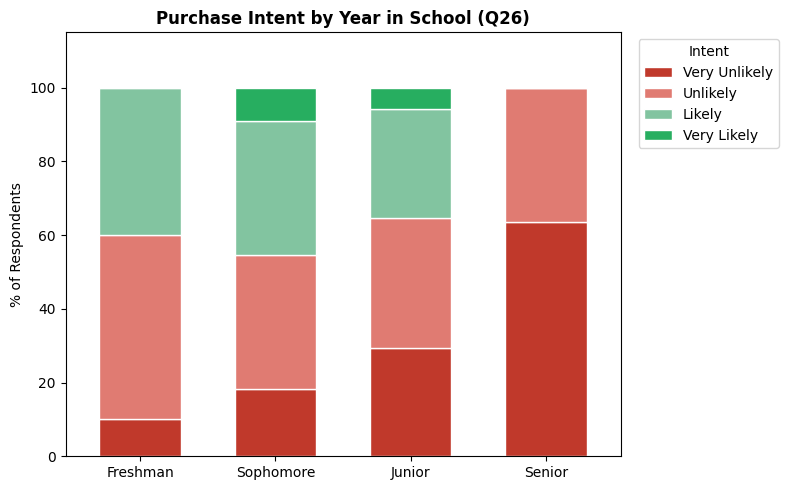

In [11]:
year_order   = ['Freshman', 'Sophomore', 'Junior', 'Senior']
intent_order = ['1- Very unlikely', '2-  Unlikely', '3- Likely', '4- Very likely']
intent_short = ['Very Unlikely', 'Unlikely', 'Likely', 'Very Likely']
colors_intent = ['#c0392b', '#e07b72', '#82c4a0', '#27ae60']

ct_year = pd.crosstab(df['Q2'], df['Q26'])
ct_year = ct_year.reindex([y for y in year_order if y in ct_year.index])
ct_year = ct_year.reindex(columns=[c for c in intent_order if c in ct_year.columns], fill_value=0)
pct_year = ct_year.div(ct_year.sum(axis=1), axis=0).mul(100)
pct_year.columns = intent_short[:len(pct_year.columns)]

fig, ax = plt.subplots(figsize=(8, 5))
pct_year.plot(kind='bar', stacked=True, ax=ax,
              color=colors_intent[:len(pct_year.columns)], edgecolor='white', width=0.6)
ax.set_title('Purchase Intent by Year in School (Q26)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% of Respondents')
ax.set_xticklabels(year_order, rotation=0)
ax.legend(title='Intent', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

## Key Takeaways

- **T-tests**: Flag which variables (if any) show significant male/female differences — these are the most actionable gender-based insights.
- **Purchase intent**: Both genders skew unlikely; the stacked bar reveals whether the gap in likeliness is material.
- **Spending**: Higher spending scores in one group suggest price-point flexibility for targeted campaigns.
- **Design prefs**: Color and logo size differences can inform product line decisions (school colors vs. neutral).
- **Year in school**: If upperclassmen or freshman show higher intent, timing promotions around orientation or graduation can amplify reach.
- **Caveats**: n=28 male, n=19 female — treat all patterns as directional, not causal.